In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('milknew.csv')

In [3]:
X = df.drop(columns=['Grade'])  # fitur
y = df['Grade']  # label

In [4]:
encoder = OrdinalEncoder(categories=[['low', 'medium', 'high']])
y_encoded = encoder.fit_transform(y.values.reshape(-1,1))


In [5]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

In [7]:
model = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(3, activation='softmax')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2774 - loss: 1.1198 - val_accuracy: 0.4529 - val_loss: 1.0916
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5298 - loss: 1.0789 - val_accuracy: 0.5235 - val_loss: 1.0758
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6185 - loss: 1.0532 - val_accuracy: 0.5588 - val_loss: 1.0600
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6178 - loss: 1.0317 - val_accuracy: 0.5529 - val_loss: 1.0413
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6373 - loss: 0.9929 - val_accuracy: 0.5824 - val_loss: 1.0111
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6607 - loss: 0.9510 - val_accuracy: 0.5765 - val_loss: 0.9677
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6419 - loss: 0.9054 - val_accuracy: 0.5647 - val_loss: 0.9274
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6330 - loss: 0.8523 - val_accuracy: 0.5706 - 

In [15]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n Accuracy Test: {acc*100:.2f}%")


 Accuracy Test: 92.92%


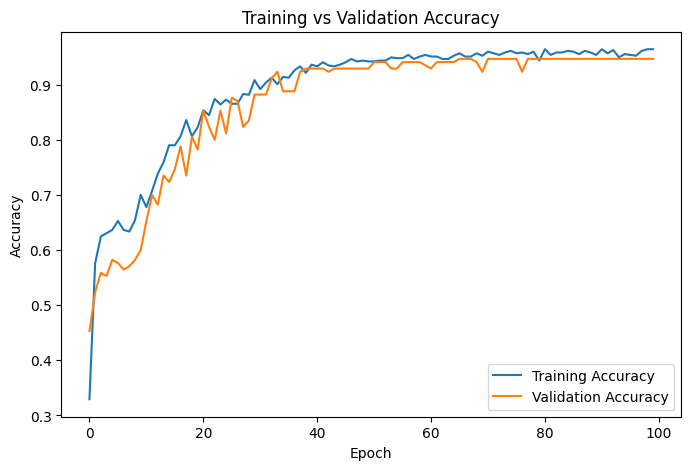

In [14]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Deep Learning
#Klasifikasi Kualitas Susu
---
## Dataset
Dataset ini berisi 1060 baris data tentang kualitas susu berdasarkan fitur seperti:
- pH
- Temperatur
- Fat
- Turbidity
- Colour
- dll.

Label target: `Grade` (low, medium, high)

---

## Model
Model menggunakan arsitektur **Sequential Neural Network** dengan:
- 3 hidden layer (32, 16, 8 neuron)
- Aktivasi ReLU pada hidden layer
- Softmax pada output layer

Loss function: `sparse_categorical_crossentropy`  
Optimizer: `Adam`

---

## Evaluasi
Model dilatih selama 100 epoch dengan batch size 32 dan mencapai akurasi di atas 70% pada training dan validation dataset.

---

## Visualisasi
Grafik di bawah menunjukkan perkembangan akurasi training dan validation tiap epoch.
Jika garis akurasi stabil dan tidak terlalu berjauhan → model *good-fit*.